In [ ]:

# @title Data Loading
import pandas as pd

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/New_York_City_Airbnb_Open_Data_1549_65.csv')

# Remove index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Function to classify data type and measurement level
def classify_variable(series):
    if series.dtype == "object":
        return "Categorical", None, "Nominal"
    if "datetime" in str(series.dtype):
        return "Categorical (Date/Time)", None, "Interval"
    if pd.api.types.is_numeric_dtype(series):
        if pd.api.types.is_integer_dtype(series):
            cont_disc = "Discrete"
        else:
            cont_disc = "Continuous"
        return "Numerical", cont_disc, "Ratio"
    return "Other", None, None

# Domain extraction
def get_domain(series):
    if series.dtype == "object":
        return list(series.dropna().unique()[:10])
    if pd.api.types.is_numeric_dtype(series):
        return f"{series.min()} to {series.max()}"
    if "datetime" in str(series.dtype):
        return f"{series.min()} to {series.max()}"
    return None

# Build summary table
summary_rows = []
for col in df.columns:
    data_type, cont_disc, level = classify_variable(df[col])
    domain = get_domain(df[col])
    summary_rows.append({
        "Variable": col,
        "Data Type": data_type,
        "Continuous/Discrete": cont_disc,
        "Level of Measurement": level,
        "Domain": domain
    })

summary_df = pd.DataFrame(summary_rows)

summary_df



,Variable,Data Type,Continuous/Discrete,Level of Measurement,Domain
0,id,Numerical,Discrete,Ratio,2539 to 36455809
1,name,Categorical,None,Nominal,"[Clean & quiet apt home by the park, Skylit Mi..."
2,host_id,Numerical,Discrete,Ratio,2438 to 273841667
3,host_name,Categorical,None,Nominal,"[John, Jennifer, LisaRoxanne, Laura, Chris, Ga..."
4,neighbourhood_group,Categorical,None,Nominal,"[Brooklyn, Manhattan, Queens, Staten Island, B..."
5,neighbourhood,Categorical,None,Nominal,"[Kensington, Midtown, Clinton Hill, East Harle..."
6,latitude,Numerical,Continuous,Ratio,40.50641 to 40.91306
7,longitude,Numerical,Continuous,Ratio,-74.24442 to -73.71299
8,room_type,Categorical,None,Nominal,"[Private room, Entire home/apt, Shared room]"
9,price,Numerical,Discrete,Ratio,0 to 10000


In [ ]:
# @title Data cleaning
# Sometimes the CSV has an 'Unnamed: 0' index column; drop if it's a duplicate index.
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Standardize column names (lowercase, strip)
df.columns = [c.strip() for c in df.columns]
df.columns = [c.replace(' ', '_') for c in df.columns]
df.columns = [c.lower() for c in df.columns]

print(df.columns.tolist())



['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [ ]:
# @title Automatic variable summary (This includes variable names along with their types , unique counts , sample values)
import numpy as np

def level_of_measure(col, ser):
    # heuristics: adjust manually if needed
    if col in ['id', 'host_id', 'calculated_host_listings_count']:
        return "Nominal (identifier / count)"
    if pd.api.types.is_datetime64_any_dtype(ser) or col in ['last_review']:
        return "Date / Time (interval)"
    if pd.api.types.is_float_dtype(ser) or pd.api.types.is_integer_dtype(ser):
        # check small set of unique values -> categorical/ordinal
        if ser.nunique() <= 10 and ser.nunique() > 2:
            return "Ordinal / Discrete"
        return "Ratio (continuous/count)"
    if pd.api.types.is_object_dtype(ser):
        # small set -> nominal category
        if ser.nunique() <= 50:
            return "Nominal (categorical)"
        return "Nominal (text)"
    return "Other"

summary_rows = []
for col in df.columns:
    ser = df[col]
    nuniq = ser.nunique(dropna=True)
    nmiss = ser.isna().sum()
    sample_vals = ser.dropna().unique()[:6].tolist()
    if pd.api.types.is_numeric_dtype(ser):
        minv = ser.min()
        maxv = ser.max()
        meanv = ser.mean()
        summary_rows.append({
            "variable": col,
            "dtype": str(ser.dtype),
            "n_unique": nuniq,
            "n_missing": int(nmiss),
            "min": minv,
            "max": maxv,
            "mean_or_sample": meanv,
            "sample_values": sample_vals,
            "level": level_of_measure(col, ser)
        })
    else:
        summary_rows.append({
            "variable": col,
            "dtype": str(ser.dtype),
            "n_unique": nuniq,
            "n_missing": int(nmiss),
            "min": "",
            "max": "",
            "mean_or_sample": "",
            "sample_values": sample_vals,
            "level": level_of_measure(col, ser)
        })

summary_df = pd.DataFrame(summary_rows)
# Reorder columns for nicer display
summary_df = summary_df[["variable","dtype","level","n_unique","n_missing","min","max","mean_or_sample","sample_values"]]
summary_df


,variable,dtype,level,n_unique,n_missing,min,max,mean_or_sample,sample_values
0,id,int64,Nominal (identifier / count),38843,0,2539,36455809,18096462.187756,"[2539, 2595, 3831, 5022, 5099, 5121]"
1,name,object,Nominal (text),38269,6,,,,"[Clean & quiet apt home by the park, Skylit Mi..."
2,host_id,int64,Nominal (identifier / count),30251,0,2438,273841667,64239145.026337,"[2787, 2845, 4869, 7192, 7322, 7356]"
3,host_name,object,Nominal (text),9886,16,,,,"[John, Jennifer, LisaRoxanne, Laura, Chris, Ga..."
4,neighbourhood_group,object,Nominal (categorical),5,0,,,,"[Brooklyn, Manhattan, Queens, Staten Island, B..."
5,neighbourhood,object,Nominal (text),218,0,,,,"[Kensington, Midtown, Clinton Hill, East Harle..."
6,latitude,float64,Ratio (continuous/count),17443,0,40.50641,40.91306,40.728134,"[40.64749, 40.75362, 40.68514, 40.79851, 40.74..."
7,longitude,float64,Ratio (continuous/count),13641,0,-74.24442,-73.71299,-73.951148,"[-73.97237, -73.98377, -73.95976, -73.94399, -..."
8,room_type,object,Nominal (categorical),3,0,,,,"[Private room, Entire home/apt, Shared room]"
9,price,int64,Ratio (continuous/count),581,0,0,10000,142.317947,"[149, 225, 89, 80, 200, 60]"


Price summary (raw):


,price
count,38843.000000
mean,142.317947
std,196.945624
min,0.000000
25%,69.000000
50%,101.000000
75%,170.000000
max,10000.000000


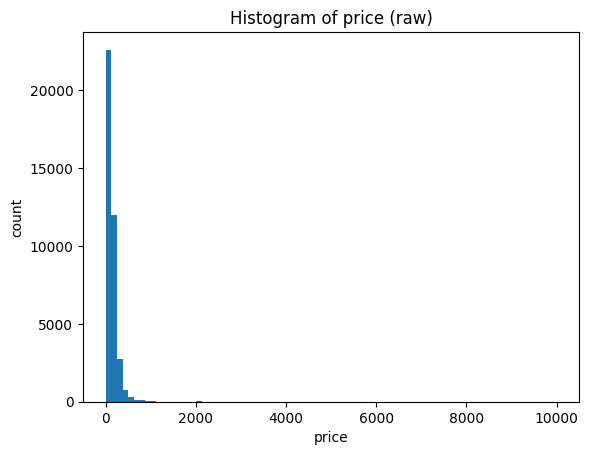

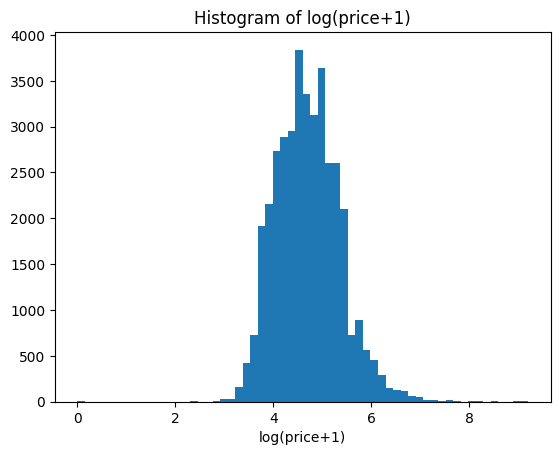

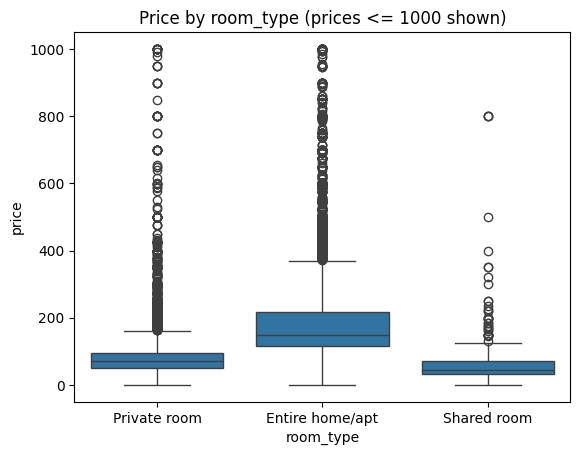

Counts of neighbourhood_group:


,count
neighbourhood_group,
Manhattan,16632
Brooklyn,16447
Queens,4574
Bronx,876
Staten Island,314


Counts of room_type:


,count
room_type,
Entire home/apt,20332
Private room,17665
Shared room,846


In [ ]:
# @title Descriptive statistics & key plots for price & other major variables
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cell D: descriptive stats
print("Price summary (raw):")
display(df['price'].describe())

# Replace suspicious zeros or extremely large outliers
plt.hist(df['price'].dropna(), bins=80)
plt.title("Histogram of price (raw)")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

# Log transform to visualise skew
df['log_price'] = np.log1p(df['price'])
plt.hist(df['log_price'].dropna(), bins=60)
plt.title("Histogram of log(price+1)")
plt.xlabel("log(price+1)")
plt.show()

# Boxplot by room_type
sns.boxplot(x='room_type', y='price', data=df[df['price']<=1000])  # cap large prices for plot
plt.title("Price by room_type (prices <= 1000 shown)")
plt.show()

# counts
print("Counts of neighbourhood_group:")
display(df['neighbourhood_group'].value_counts())
print("Counts of room_type:")
display(df['room_type'].value_counts())

In [ ]:
# @title Data Cleaning Decisions
# Cell E: cleaning decisions
# 1) Remove listings with price <= 0
df = df[df['price'] > 0].copy()

# 2) Optionally remove extreme price outliers for some analyses
upper = df['price'].quantile(0.995)  # 99.5th percentile
print("99.5th percentile of price:", upper)
df_trim = df[df['price'] <= upper].copy()

# 3) For analyses that require both groups, drop rows with missing key fields
df_trim = df_trim.dropna(subset=['room_type','neighbourhood_group','price'])
df_trim.shape


99.5th percentile of price: 889.679999999993


(38638, 17)

In [ ]:
# @title Confidence Intervals
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint

# Cell F: Confidence intervals

# 1) CI for mean price (95%) using trimmed dataset
prices = df_trim['price'].dropna()
n = len(prices)
mean = prices.mean()
se = stats.sem(prices)
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
print(f"Mean price = {mean:.2f}, n={n}, 95% CI = ({ci[0]:.2f}, {ci[1]:.2f})")

# 2) CI for proportion: proportion of listings that are Entire home/apt
count_entire = (df_trim['room_type']=="Entire home/apt").sum()
n_total = len(df_trim)
prop = count_entire / n_total
ci_low, ci_upp = proportion_confint(count_entire, n_total, alpha=0.05, method='wilson')
print(f"Proportion Entire home/apt = {prop:.4f}, 95% CI = ({ci_low:.4f}, {ci_upp:.4f})")

Mean price = 134.00, n=38638, 95% CI = (132.99, 135.01)
Proportion Entire home/apt = 0.5220, 95% CI = (0.5170, 0.5270)


In [ ]:
# @title One Sample t-test
# Cell G: one-sample t-test: H0: mean price = 150
mu0 = 150
t_stat, pval = stats.ttest_1samp(prices, popmean=mu0)
print("One-sample t-test vs $150: t =", t_stat, "p =", pval)
# Compute CI for mean difference to mu0: mean - mu0
diff = mean - mu0
print(f"Mean - {mu0} = {diff:.2f}")


One-sample t-test vs $150: t = -31.063795073693335 p = 2.8194880460601995e-209
Mean - 150 = -16.00


In [ ]:
# @title Two sample t-test

# TWO-SAMPLE T-TEST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf



print("\n TWO-SAMPLE T-TEST: Entire Home vs Private Room ")

# Extract groups
g_entire = df_trim[df_trim['room_type']=="Entire home/apt"]['price']
g_private = df_trim[df_trim['room_type']=="Private room"]['price']

# Print hypotheses
print("H0: Mean price of Entire homes = Mean price of Private rooms")
print("Ha: Mean price of the two groups are different\n")

# Welch t-test
t_stat, pval = stats.ttest_ind(g_entire, g_private, equal_var=False, nan_policy='omit')

print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {pval:.6f}")
print(f"n_entire = {len(g_entire)}, n_private = {len(g_private)}")

# Mean difference + 95% CI
diff = g_entire.mean() - g_private.mean()
se_diff = np.sqrt(g_entire.var(ddof=1)/len(g_entire) + g_private.var(ddof=1)/len(g_private))
df_welch = (g_entire.var(ddof=1)/len(g_entire) + g_private.var(ddof=1)/len(g_private))**2 / \
    ((g_entire.var(ddof=1)/len(g_entire))**2/(len(g_entire)-1) + (g_private.var(ddof=1)/len(g_private))**2/(len(g_private)-1))

ci_low = diff - stats.t.ppf(0.975, df_welch)*se_diff
ci_high = diff + stats.t.ppf(0.975, df_welch)*se_diff

print(f"\nMean difference (Entire - Private) = {diff:.2f}")
print(f"95% CI = ({ci_low:.2f}, {ci_high:.2f})")

# Interpretation
if pval < 0.05:
    print("\nConclusion: Reject H0 → The average prices ARE significantly different.")
else:
    print("\nConclusion: Fail to Reject H0 → No significant difference in average prices.")



 TWO-SAMPLE T-TEST: Entire Home vs Private Room 
H0: Mean price of Entire homes = Mean price of Private rooms
Ha: Mean price of the two groups are different

t-statistic = 119.4635
p-value = 0.000000
n_entire = 20169, n_private = 17627

Mean difference (Entire - Private) = 103.16
95% CI = (101.47, 104.85)

Conclusion: Reject H0 → The average prices ARE significantly different.


In [ ]:
# @title Chi square tests
# CHI-SQUARE TESTS


print("\n CHI-SQUARE: Goodness of Fit — Neighbourhood Group ")

obs = df_trim['neighbourhood_group'].value_counts().sort_index()
expected = np.repeat(len(df_trim)/len(obs), len(obs))

print("H0: All neighbourhood_groups appear equally often.")
print("Ha: At least one borough appears more/less often than expected.\n")

chi2, pval = stats.chisquare(obs, expected)

print(f"Chi-square = {chi2:.4f}")
print(f"p-value = {pval:.6f}")
print("Observed Counts:")
print(obs)

if pval < 0.05:
    print("\nConclusion: Reject H0 → Neighbourhood distribution is NOT uniform.")
else:
    print("\nConclusion: Fail to Reject H0 → Looks uniform.")



# Independence Test


print("\n CHI-SQUARE: Independence Test (room_type × neighbourhood_group) ")

print("H0: room_type and neighbourhood_group are independent.")
print("Ha: They are associated.\n")

ct = pd.crosstab(df_trim['room_type'], df_trim['neighbourhood_group'])
chi2_stat, p, dof, expected = stats.chi2_contingency(ct)

print(f"Chi-square = {chi2_stat:.4f}")
print(f"p-value = {p:.6f}")
print(f"Degrees of freedom = {dof}\n")

print("Contingency Table:")
display(ct)

if p < 0.05:
    print("\nConclusion: Reject H0 → room_type and neighbourhood_group ARE related.")
else:
    print("\nConclusion: Fail to Reject H0 → No association found.")




 CHI-SQUARE: Goodness of Fit — Neighbourhood Group 
H0: All neighbourhood_groups appear equally often.
Ha: At least one borough appears more/less often than expected.

Chi-square = 34129.0348
p-value = 0.000000
Observed Counts:
neighbourhood_group
Bronx              875
Brooklyn         16398
Manhattan        16483
Queens            4568
Staten Island      314
Name: count, dtype: int64

Conclusion: Reject H0 → Neighbourhood distribution is NOT uniform.

 CHI-SQUARE: Independence Test (room_type × neighbourhood_group) 
H0: room_type and neighbourhood_group are independent.
Ha: They are associated.

Chi-square = 935.0006
p-value = 0.000000
Degrees of freedom = 8

Contingency Table:


neighbourhood_group,Bronx,Brooklyn,Manhattan,Queens,Staten Island
room_type,,,,,
Entire home/apt,309,8132,9838,1740,150
Private room,523,7978,6289,2678,159
Shared room,43,288,356,150,5



Conclusion: Reject H0 → room_type and neighbourhood_group ARE related.



 SIMPLE LINEAR REGRESSION: log(price) ~ number_of_reviews 
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     15.05
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           0.000105
Time:                        22:50:23   Log-Likelihood:                -37075.
No. Observations:               38638   AIC:                         7.415e+04
Df Residuals:                   38636   BIC:                         7.417e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

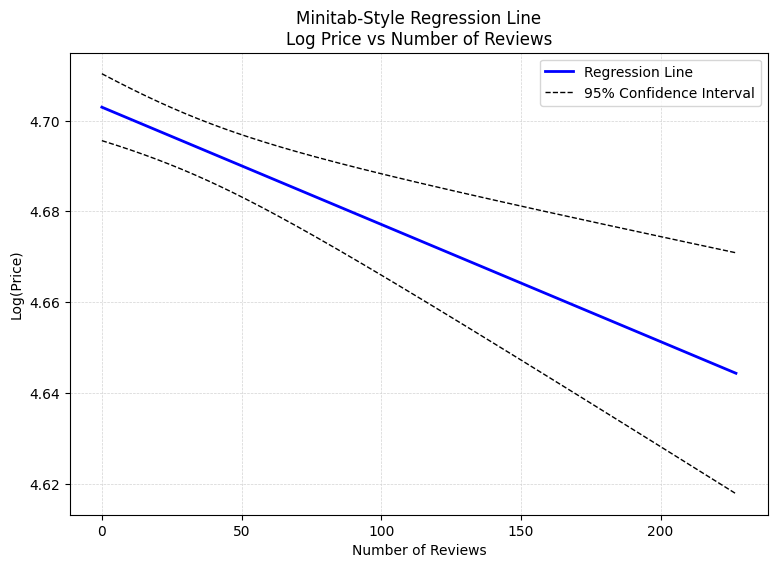


Conclusion:
The slope is statistically significant → number_of_reviews predicts price.


In [ ]:
# @title Simple Linear Regression

# Fit model
mod = smf.ols('log_price ~ number_of_reviews', data=df_trim).fit()
print("\n SIMPLE LINEAR REGRESSION: log(price) ~ number_of_reviews ")
print(mod.summary())

# Prepare prediction range
x_vals = np.linspace(0, df_trim['number_of_reviews'].quantile(0.99), 200)
pred_df = pd.DataFrame({'number_of_reviews': x_vals})

# Predictions and 95% CI
predictions = mod.get_prediction(pred_df)
pred_summary = predictions.summary_frame(alpha=0.05)




plt.figure(figsize=(9,6))

# Regression line
plt.plot(x_vals, pred_summary['mean'],
         color='blue', linewidth=2, label="Regression Line")

# Confidence Bands (upper & lower)
plt.plot(x_vals, pred_summary['mean_ci_lower'],
         color='black', linestyle='--', linewidth=1,
         label="95% Confidence Interval")
plt.plot(x_vals, pred_summary['mean_ci_upper'],
         color='black', linestyle='--', linewidth=1)

# Labels and title
plt.xlabel("Number of Reviews")
plt.ylabel("Log(Price)")
plt.title("Minitab-Style Regression Line\nLog Price vs Number of Reviews")

# Light clean grid
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)

plt.legend()
plt.show()

# Interpretation
print("\nConclusion:")
if mod.pvalues['number_of_reviews'] < 0.05:
    print("The slope is statistically significant → number_of_reviews predicts price.")
else:
    print("The slope is NOT significant → number_of_reviews does not predict price.")


